# Phase 2: Data Pipeline

Phase 1 was exploratory and answered "do we have enough data?"
(Yes, 1,713 four-signal films). Phase 2 turns the raw downloads
into the canonical processed artifact every later phase will
consume:

* `data/processed/films_joined.parquet`: one row per film, with all
  source columns, derived columns (`effective_rating`,
  `log_budget`, `log_revenue`, `primary_genre`, `genres_bucketed`,
  `primary_genre_bucketed`), and screenplay-structural metrics
  (`n_scenes`, `n_unique_characters`, `n_dialogue_lines`,
  character / action / dialogue char counts, two ratios).
* `data/processed/screenplays_parsed.pkl`: pickle of
  `dict[imdb_id, ParsedScreenplay]` with the full per-scene
  structure (dialogue units, stage directions, scene
  descriptions). Phase 3 reads both files.

Every preprocessing choice in this notebook has a rationale tied
to a Phase 1 EDA observation. The structure below mirrors how
the production pipeline runs (see `src/data/build_corpus.py`)
but pauses at each step so you can see the data, the choice, and
the reason. Run cells top to bottom.

## 0. Setup

The bootstrap cell finds the project root (by walking up until
`docs/PROJECT_CONTEXT.md` is found) and adds it to `sys.path` so
`from src... import ...` works regardless of where this notebook
lives. It also enables `%autoreload 2`, which means edits to any
`src/data/*.py` file flow into the notebook automatically without
a kernel restart.

In [1]:
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    """Walk up the tree until we find docs/PROJECT_CONTEXT.{md,txt}."""
    markers = ("docs/PROJECT_CONTEXT.md", "docs/PROJECT_CONTEXT.txt")
    for candidate in (start.resolve(), *start.resolve().parents):
        if any((candidate / m).is_file() for m in markers):
            return candidate
    raise RuntimeError(f"Could not find project root from {start!s}.")


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

# Auto-reload modules when their source files change.
get_ipython().run_line_magic("load_ext", "autoreload")
get_ipython().run_line_magic("autoreload", "2")

get_ipython().run_line_magic("matplotlib", "inline")

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Project root: C:\Users\antho\Documents\GitHub\MSBA_315_Final_Project


Common imports the rest of the notebook will use.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import paths

paths.ensure_dirs()

print("Data raw dir:    ", paths.DATA_RAW_DIR)
print("Data interim:    ", paths.DATA_INTERIM_DIR)
print("Data processed:  ", paths.DATA_PROCESSED_DIR)
print("Reports figures: ", paths.REPORTS_FIGURES_DIR)

Data raw dir:     C:\Users\antho\Documents\GitHub\MSBA_315_Final_Project\data\raw
Data interim:     C:\Users\antho\Documents\GitHub\MSBA_315_Final_Project\data\interim
Data processed:   C:\Users\antho\Documents\GitHub\MSBA_315_Final_Project\data\processed
Reports figures:  C:\Users\antho\Documents\GitHub\MSBA_315_Final_Project\reports\figures


---

## 1. Load the raw data

Both datasets are loaded by their respective loaders. Phase 1
verified these are production-quality (type hints, docstrings,
validation, INFO/DEBUG logging), so we use them as-is in Phase 2.

**The ratings dataset** (~1.07M rows) is column-selective on
purpose. We only read the ~20 columns we need; reading the full
42-column file uses 3-4 GB of memory.

**MovieSum** is the screenplay corpus: 2,200 XML scripts across
train / val / test JSONL files. The original train/val/test
split is for the dataset's authors' upstream summarization task,
not ours; we'll redo splits in Phase 3.

In [3]:
from src.data.load_ratings import load_ratings, summarize_ratings
from src.data.load_moviesum import load_moviesum, imdb_id_validity

# ~20-30s on first load; reads the IMDb-TMDB metadata CSV.
ratings = load_ratings()
print(f"Ratings raw:    {len(ratings):,} films, {len(ratings.columns)} columns")
print(f"  Headline counts: {summarize_ratings(ratings)}")

# ~5-10s; reads ~450 MB of JSONL across the three MovieSum splits.
moviesum = load_moviesum()
print(f"MovieSum raw:   {len(moviesum):,} screenplays")
print(f"  IMDb ID validity: {imdb_id_validity(moviesum)}")

2026-05-03 23:29:53 | INFO    | src.data.load_ratings | Loading ratings dataset (~20-30s)
2026-05-03 23:30:08 | INFO    | src.data.load_ratings | Loaded ratings: 1,072,255 rows | 588,585 unique IMDb IDs | 1,071,607 unique TMDB ids
Ratings raw:    1,072,255 films, 22 columns
  Headline counts: {'total': 1072255, 'with_budget': 54415, 'with_revenue': 20264, 'with_both': 13759, 'with_imdb_id': 589364}
2026-05-03 23:30:08 | INFO    | src.data.load_moviesum | Loading MovieSum (train + val + test, ~5-10s)
2026-05-03 23:30:10 | INFO    | src.data.load_moviesum | Loaded MovieSum: 2,200 screenplays
MovieSum raw:   2,200 screenplays
  IMDb ID validity: {'total': 2200, 'valid_imdb_id': 2200, 'invalid_or_missing': 0, 'unique_valid_ids': 2188}


Note the second number in MovieSum's IMDb ID validity output:
2,188 unique IDs across 2,200 rows. Twelve IDs appear twice,
which is the duplicate-pair issue Phase 1 surfaced and you
reviewed manually. The dedup happens in step 3 below.

---

## 2. Dedupe the ratings dataset on `imdb_id`

**Why this step exists.** A small fraction of films appear in
the ratings dataset under more than one TMDB `id` for the same
IMDb ID. These are alternate cuts, regional releases, or
director's cuts. For our purposes they're the same film, and
joining MovieSum to all variants would create spurious
duplicates downstream.

**The choice.** Keep the row with the highest `vote_count`
(better-known variant, also more likely to have populated budget
/ revenue / rating fields). Drop the others. Films with no IMDb
ID at all get dropped here too since they can't be joined to
MovieSum.

**Why `vote_count` rather than `popularity` or `vote_average`?**
`vote_count` is robustly populated and uses the same scale across
eras, whereas `popularity` is recency-biased and `vote_average`
is a quality measure not a recognition measure.

In [4]:
from src.data.join_corpus import dedupe_ratings

# `dedupe_ratings` lives in src/data/join_corpus.py. It drops rows
# without an imdb_id and keeps the row with the highest vote_count
# per imdb_id. Implementation reads ratings_dedup.shape and
# logs the before/after counts via the project logger.
ratings_dedup = dedupe_ratings(ratings)
print(f"Ratings deduped: {len(ratings_dedup):,} films "
      f"(was {len(ratings):,} before)")

2026-05-03 23:30:11 | INFO    | src.data.join_corpus | Dedup ratings by IMDb ID: 1072255 → 588585 (483670 dropped, 482891 had no IMDb ID)
Ratings deduped: 588,585 films (was 1,072,255 before)


---

## 3. Dedupe MovieSum using the user-filled review CSV

**Why this step exists.** MovieSum has 12 IMDb IDs that appear
on two rows each. Phase 1's `review_duplicates.py` printed the
24 rows side-by-side with structural counts and script
previews; you went through each pair and decided which row to
keep. Your decisions live in
`reports/tables/phase1_moviesum_duplicates_review.csv` (the
`decision` column).

**Why this approach over a heuristic.** Phase 1 considered an
automatic "keep the longest script" rule, but the pairs aren't
all of the same kind. Some are spelling variants of the same
script (M\*A\*S\*H / MASH); others are genuinely different
drafts of the same film (Star Wars / Episode IV); a few are
from different MovieSum splits (train vs test) where we want to
avoid the test copy. Human judgement per pair gives a cleaner
result than a single heuristic.

**What happens if the CSV is malformed.** The pipeline raises
loudly. If a row's decision is missing, unrecognized, or if a
pair doesn't have exactly one `keep` and one `drop`, the
function won't silently default to anything; you'd see a
`ValueError` and we'd revisit the CSV. (The function accepts
`keep` and `drop` / `remove` / `delete` / `discard` synonyms; the
original Phase 1 review used `remove`.)

In [5]:
# Show a slice of the review CSV so you can confirm what's being applied.
review_csv = paths.REPORTS_TABLES_DIR / "phase1_moviesum_duplicates_review.csv"
review_df = pd.read_csv(review_csv)
print(f"Review CSV: {len(review_df)} rows, "
      f"{review_df['imdb_id'].nunique()} unique IMDb IDs")
print(f"Decision values: {review_df['decision'].value_counts(dropna=False).to_dict()}")
review_df[["imdb_id", "movie_name", "year_in_title", "origin_split",
           "script_char_len", "decision"]].head(10)

Review CSV: 24 rows, 12 unique IMDb IDs
Decision values: {'keep': 12, 'remove': 12}


,imdb_id,movie_name,year_in_title,origin_split,script_char_len,decision
0,tt0066026,M*A*S*H_1970,1970,train,256088,keep
1,tt0066026,MASH_1970,1970,train,255631,remove
2,tt0076759,Star Wars_1977,1977,train,308467,remove
3,tt0076759,Star Wars: Episode IV - A New Hope_1977,1977,train,306230,keep
4,tt0082971,Indiana Jones and the Raiders of the Lost Ark_...,1981,train,212926,keep
5,tt0082971,Raiders of the Lost Ark_1981,1981,train,210507,remove
6,tt0083972,Friday the 13th Part III_1982,1982,train,151784,remove
7,tt0083972,Friday the 13th: Part 3_1982,1982,train,149919,keep
8,tt0109836,Mary Shelley's Frankenstein_1994,1994,test,253890,keep
9,tt0109836,Frankenstein_1994,1994,train,249586,remove


In [6]:
from src.data.build_corpus import dedupe_moviesum_from_csv

# Apply your per-pair decisions. Drops one row from each duplicate
# pair, keeping the row you marked `keep`.
moviesum_dedup = dedupe_moviesum_from_csv(moviesum, review_csv)
print(f"MovieSum deduped: {len(moviesum_dedup):,} films "
      f"(was {len(moviesum):,} before)")

2026-05-03 23:30:11 | INFO    | src.data.build_corpus | Dedup MovieSum from review CSV: 2200 → 2188 (12 dropped per user decisions)
MovieSum deduped: 2,188 films (was 2,200 before)


---

## 4. Join MovieSum × ratings on `imdb_id`

**Why direct ID join (no fuzzy matching).** The ratings dataset
carries IMDb IDs (`imdb_id`, `tt`-prefixed) and TMDB IDs (`id`)
natively, and so does MovieSum. So the join is a single line of
pandas with no normalization or fuzzy logic. The original Phase 1
plan used title+year fuzzy matching against TMDB 5000 (which
lacks IMDb IDs), but the dataset swap to the IMDb-TMDB 1M
dataset eliminated that complication.

**Note on suffixes.** Both DataFrames have a `title` column
(MovieSum's is the title with the year suffix stripped; the
ratings side has the canonical TMDB title). When pandas merges
them, it adds suffixes: `title_ms` and `title_rt`. The `title_ms`
column is the one we use for human-readable output downstream.

In [7]:
from src.data.join_corpus import join_corpora

# Left-merge on imdb_id with our standard suffixes. ms = MovieSum,
# rt = ratings.
joined = join_corpora(moviesum_dedup, ratings_dedup)
n_matched = joined["id"].notna().sum()
print(f"Joined: {len(joined):,} rows; "
      f"{n_matched:,} matched ({100*n_matched/len(joined):.1f}%)")
print(f"Columns: {len(joined.columns)}")

# Show a few rows to confirm the merge looks right.
joined[["imdb_id", "movie_name", "title_rt", "release_year_parsed",
        "budget", "revenue", "IMDB_Rating"]].head()

Joined: 2,188 rows; 2,186 matched (99.9%)
Columns: 27


,imdb_id,movie_name,title_rt,release_year_parsed,budget,revenue,IMDB_Rating
0,tt0134273,8MM_1999,8MM,1999,40000000.0,96618699.0,NaN
1,tt1007029,The Iron Lady_2011,The Iron Lady,2011,13000000.0,115890699.0,7.6
2,tt1091722,Adventureland_2009,Adventureland,2009,9800000.0,17164820.0,7.9
3,tt13287846,Napoleon_2023,Napoleon,2023,0.0,0.0,NaN
4,tt4302938,Kubo and the Two Strings_2016,Kubo and the Two Strings,2016,60000000.0,76249438.0,7.8


---

## 5. Apply the corpus filters

Five filters in this step. Each has a specific reason from EDA.
We apply them in order so the count drops are interpretable.

**Filter 1: Drop unmatched MovieSum rows.** Two films from
MovieSum aren't in the ratings dataset at all. We can't use a
film with no rating / budget / revenue, so they're dropped here.

**Filter 2: Drop films with `budget == 0`.** TMDB stores missing
financial data as integer `0` (CSV INT columns can't hold NaN,
so the dataset's authors use `0` as a sentinel). Phase 1 EDA
confirmed this with a direct check: 0 NaN values for budget,
but ~95% of all films have `budget=0`. We need real budget
values to model financial outcomes, so we use a `> 0` filter.

**Filter 3: Drop films with `revenue == 0`.** Same convention
as budget. The two filters together produce the "four-signal"
subset the project depends on.

**Filter 4: Drop films with no rating.** A film must have either
a populated `IMDB_Rating` or `vote_average` to be useful as a
regression target. The two combined catch ~all matched films
in practice (no films were dropped here in this run).

**Filter 5: Year clip to [1900, 2025].** A handful of rows in
the raw ratings dataset have nonsense future years (2055, 2099
etc.). These are scheduled releases or noise. The clip removes
them defensively.

**The non-filter: pre-1995 cutoff.** The Phase 2 brief locked in
a 1995 cutoff based on the Phase 1 EDA's claim of "~50 pre-1995
films." When the build first ran with that cutoff, the corpus
came in at 1,315 films, well below the 1,400 floor. Investigation
showed the actual pre-1995 count was 398 films, not ~50; the
Phase 1 EDA had miscounted. The cutoff was reversed (decision
log entry 2026-05-02 23:35) and we keep all 1,713 films. The
`min_year` knob in `CorpusBuildConfig` defaults to 1900 (no
effective cutoff), but is exposed for future experimentation.

In [8]:
from src.data.build_corpus import apply_corpus_filters, CorpusBuildConfig

# Use the default config (min_year=1900 = no cutoff after the reversal).
config = CorpusBuildConfig()
print(f"Active filters from config:")
print(f"  min_year:        {config.min_year}  (1900 = no cutoff after reversal)")
print(f"  year_clip:       [{config.year_clip_min}, {config.year_clip_max}]")

filtered = apply_corpus_filters(joined, config)
print(f"\nFiltered corpus: {len(filtered):,} films")

Active filters from config:
  min_year:        1900  (1900 = no cutoff after reversal)
  year_clip:       [1900, 2025]
2026-05-03 23:30:12 | INFO    | src.data.build_corpus | Corpus filters: 2188 → unmatched 2186 → no $ 1713 → no rating 1713 → year_clip 1713 → min_year(1900) 1713

Filtered corpus: 1,713 films


The INFO log line above shows the count drop at each filter
step. Read left to right: starting count → after each filter.
The big drop is filter 2/3 (zero-budget/revenue): 2,186 → 1,713.
The remaining filters in this run don't drop anyone (all rows
already pass them).

At this point we have **1,713 films** with all four required
signals, year range 1932 to 2023.

---

## 6. Compute the derived columns

Derived columns are convenience features computed from raw
columns. They live in the master Parquet so downstream phases
don't have to recompute them. There are six derivatives.

### 6.1 `effective_rating`

**Why.** The ratings dataset has multiple rating columns:
`IMDB_Rating` (IMDb's 0-10 user rating), `vote_average` (TMDB's
0-10 user rating), `AverageRating` (smoothed/external),
`Meta_score` (Metacritic 0-100). Different scales, different
coverage. Phase 4 needs a single rating column to predict.

**Choice.** Use `IMDB_Rating` when it's populated and non-zero;
fall back to `vote_average` when it isn't. We exclude
`AverageRating` and `Meta_score` because (a) they have different
scales and (b) they're sparser. We treat 0 as a missing-value
sentinel for the rating columns too, by analogy with the budget
/ revenue convention.

**Mean values.** `IMDB_Rating` averages around 7.0 on this
corpus; `vote_average` averages around 6.7 (TMDB ratings tend
slightly lower than IMDb's on the same films). The combined
`effective_rating` averages 6.94.

In [9]:
from src.data.build_corpus import compute_effective_rating

# The rating_priority knob is a tuple of column names. The function
# walks them in order and uses the first non-null, non-zero value.
eff_rating = compute_effective_rating(filtered, config.rating_priority)

# Compare the source columns and the derived effective_rating.
comparison = pd.DataFrame({
    "IMDB_Rating": filtered["IMDB_Rating"],
    "vote_average": filtered["vote_average"],
    "effective_rating": eff_rating,
})
print(f"Coverage:")
print(f"  IMDB_Rating populated:   {(filtered['IMDB_Rating'] > 0).sum():,}")
print(f"  vote_average populated:  {(filtered['vote_average'] > 0).sum():,}")
print(f"  effective_rating final:  {eff_rating.notna().sum():,}")
print(f"\nMeans:")
print(comparison[comparison > 0].mean().round(3))

Coverage:
  IMDB_Rating populated:   1,267
  vote_average populated:  1,713
  effective_rating final:  1,713

Means:
IMDB_Rating         7.101
vote_average        6.873
effective_rating    6.943
dtype: float64


### 6.2 `log_budget` and `log_revenue`

**Why log-transform.** Phase 1 EDA showed both budget and
revenue are heavily right-skewed: mean is much larger than
median, max is much larger than the 75th percentile, and a few
$300M+ blockbusters dominate. If we used raw values as features
or targets, those few outliers would dominate any squared-error
loss. Log-transforming compresses the right tail into something
roughly normal, which is friendlier to most ML models.

**Choice of `log1p`.** `log1p(x) = log(1 + x)` rather than plain
`log(x)`. The `+1` handles `x = 0`. Our filter
already excludes zero-valued rows, so plain `log` would also
work, but `log1p` is defensive and standard.

**Saving both raw and log.** Downstream phases pick whichever
form is appropriate for the task at hand. Some models prefer
the raw value (e.g., interpretable-coefficient regressions);
most prefer the log.

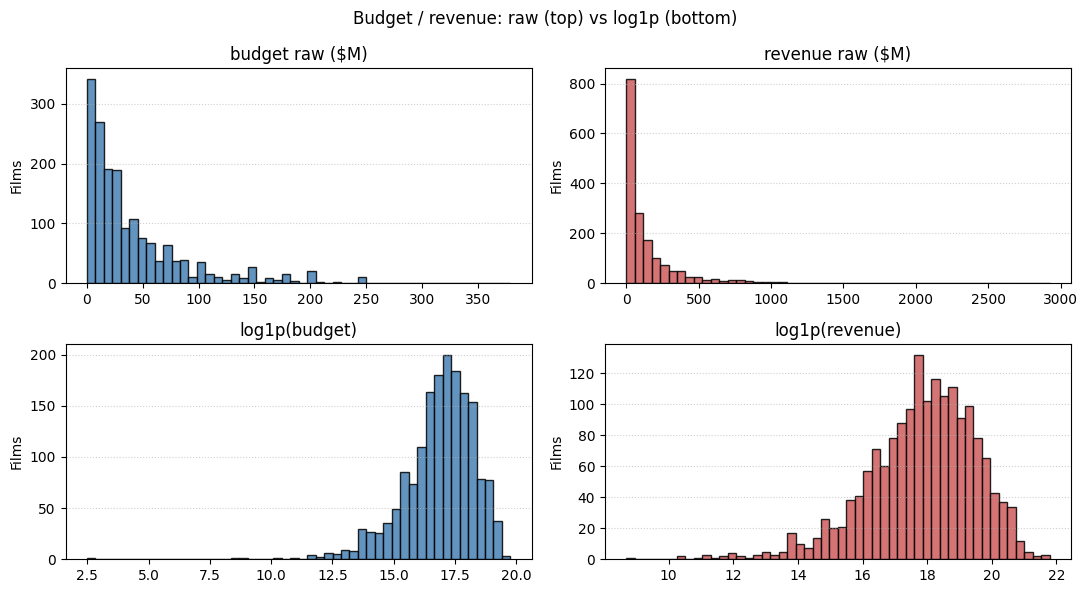

In [10]:
from src.data.build_corpus import compute_monetary_log

log_budget = compute_monetary_log(filtered["budget"], config.monetary_transform)
log_revenue = compute_monetary_log(filtered["revenue"], config.monetary_transform)

# Compare distributions side by side.
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for col, raw, log_v, color, ax_top, ax_bot in (
    ("budget", filtered["budget"], log_budget, "steelblue", axes[0, 0], axes[1, 0]),
    ("revenue", filtered["revenue"], log_revenue, "indianred", axes[0, 1], axes[1, 1]),
):
    ax_top.hist(raw / 1e6, bins=50, color=color, edgecolor="black", alpha=0.85)
    ax_top.set(title=f"{col} raw ($M)", ylabel="Films")
    ax_top.grid(axis="y", linestyle=":", alpha=0.6)

    ax_bot.hist(log_v, bins=50, color=color, edgecolor="black", alpha=0.85)
    ax_bot.set(title=f"log1p({col})", ylabel="Films")
    ax_bot.grid(axis="y", linestyle=":", alpha=0.6)
fig.suptitle("Budget / revenue: raw (top) vs log1p (bottom)")
fig.tight_layout()
plt.show()

The bottom row shows what we want: roughly bell-shaped
distributions with the heavy tail compressed. Phase 4 features
and (where appropriate) targets will use these log columns.

### 6.3 `primary_genre`, `genres_bucketed`, `primary_genre_bucketed`

**Why bucket the long tail.** Phase 1 EDA showed Drama, Comedy,
Thriller, Action dominate the genre distribution; Documentary,
TV Movie, Foreign, Western, etc. have very thin counts. For
per-genre cross-validation slices in Phase 4 we need cells with
at least ~30 films, otherwise the per-genre estimates are too
noisy to be useful.

**Threshold.** 30 films is the `genre_min_count` knob default;
anything below that collapses into `Other`. The threshold is
exposed as a knob so we can tune it later (e.g., raise to 50 if
Phase 4 reveals 30 was too generous).

**Three columns.** Most films have multiple genres, so we save
both the multi-label `genres_bucketed` (a list of strings, with
thin genres replaced by `Other`) and the single-label
`primary_genre_bucketed` (the first listed genre, similarly
bucketed). We also save `primary_genre` (no bucketing) for
traceability. Phase 4 picks whichever is appropriate per task
(per-genre stratification uses the bucketed primary; multi-label
feature engineering uses the bucketed list).

In [11]:
from src.data.build_corpus import (
    compute_primary_genre, bucket_genres,
)

primary_genre = filtered["genres_parsed"].map(compute_primary_genre)
genres_bucketed, primary_bucketed, kept_genres = bucket_genres(
    filtered.assign(primary_genre=primary_genre),
    config.genre_min_count,
)
print(f"Genres kept (≥{config.genre_min_count} films):")
print(sorted(kept_genres))

# Show the effect of bucketing on the primary-genre distribution.
pre = primary_genre.value_counts()
post = primary_bucketed.value_counts()
print(f"\nUnique primary_genre BEFORE bucketing: {pre.size}")
print(f"Unique primary_genre AFTER bucketing:  {post.size}")
print(f"\nFilms collapsed into 'Other': "
      f"{post.get('Other', 0):,} of {len(filtered):,}")

Genres kept (≥30 films):
['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'Thriller', 'War']

Unique primary_genre BEFORE bucketing: 17
Unique primary_genre AFTER bucketing:  17

Films collapsed into 'Other': 8 of 1,713


Putting all derived columns together via the convenience function:

In [12]:
from src.data.build_corpus import add_derived_columns

derived = add_derived_columns(filtered, config)
print(f"Corpus with derived columns: {len(derived):,} rows × "
      f"{len(derived.columns)} cols")
print(f"\nNew columns:")
new_cols = [c for c in derived.columns if c not in filtered.columns]
for c in new_cols:
    print(f"  {c}")

2026-05-03 23:30:13 | INFO    | src.data.build_corpus | Derived columns added. Kept genres (≥30 films): ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'Thriller', 'War']
Corpus with derived columns: 1,713 rows × 33 cols

New columns:
  effective_rating
  log_budget
  log_revenue
  primary_genre
  genres_bucketed
  primary_genre_bucketed


---

## 7. Parse the screenplay XML

**Why this step exists.** Phase 1 confirmed MovieSum's XML
structure but didn't actually parse it. Phase 2 builds the
parser that converts each `script` string into a structured
`ParsedScreenplay` object containing a list of `Scene` objects,
each with stage directions, scene descriptions, and ordered
`(character, dialogue_text)` pairs.

**What we get from the parser** (per film):

* The full per-scene structure (saved in the pickle).
* Structural metrics denormalized onto the master DataFrame:
  `n_scenes`, `n_unique_characters`, `n_dialogue_lines`,
  `total_dialogue_chars`, `total_stage_direction_chars`,
  `total_scene_description_chars`, `total_action_chars`,
  and two ratios.

**Edge cases handled.** Malformed XML returns a degenerate
object (no crash). The `<parenthetical>` tag (which the brief
didn't document, but which appears in MovieSum as
`(softly)`-style stage cues) is recognized as a continuation
marker so dialogue lines after a parenthetical correctly
attribute to the same speaker.

**Why two ratios.** The brief defined `dialogue_to_action_ratio
= dialogue / (dialogue + stage_direction)`. In MovieSum,
`stage_direction` is usually just the slugline ("INT. KITCHEN
- DAY"), so this literal formula yields values close to 1 for
most scripts. We also save
`dialogue_to_total_text_ratio = dialogue / (dialogue +
stage_direction + scene_description)`, which is a more
informative measure of how dialogue-heavy a script is (mean
0.40 in our corpus). Phase 4 picks whichever is more useful
per feature.

### 7.1 Look at one parsed screenplay

In [13]:
from src.data.parse_screenplay import parse_screenplay

# Take one example to show the structure.
sample = derived.iloc[0]
parsed_one = parse_screenplay(sample["script"], sample["imdb_id"])

print(f"Parsed: {sample['movie_name']}")
print(f"  imdb_id:                       {parsed_one.imdb_id}")
print(f"  n_scenes:                      {parsed_one.n_scenes}")
print(f"  n_unique_characters:           {parsed_one.n_unique_characters}")
print(f"  n_dialogue_lines:              {parsed_one.n_dialogue_lines}")
print(f"  total_dialogue_chars:          {parsed_one.total_dialogue_chars:,}")
print(f"  total_action_chars:            {parsed_one.total_action_chars:,}")
print(f"  dialogue_to_action_ratio:      {parsed_one.dialogue_to_action_ratio:.3f}")
print(f"  dialogue_to_total_text_ratio:  {parsed_one.dialogue_to_total_text_ratio:.3f}")
print(f"  parse_warnings:                {len(parsed_one.parse_warnings)}")

Parsed: 8MM_1999
  imdb_id:                       tt0134273
  n_scenes:                      282
  n_unique_characters:           31
  n_dialogue_lines:              871
  total_dialogue_chars:          55,728
  total_action_chars:            117,101
  dialogue_to_action_ratio:      0.846
  dialogue_to_total_text_ratio:  0.322
  parse_warnings:                0


And one scene from that screenplay (just to see the data shape):

In [14]:
first_scene = parsed_one.scenes[0]
print(f"Scene {first_scene.scene_number}:")
print(f"  stage_direction:   {first_scene.stage_direction[:100]!r}")
print(f"  scene_description: {first_scene.scene_description[:120]!r}")
print(f"  n dialogue_units:  {len(first_scene.dialogue_units)}")
if first_scene.dialogue_units:
    for char, line in first_scene.dialogue_units[:3]:
        print(f"    {char}: {line[:80]!r}")

Scene 1:
  stage_direction:   'INT.  MIAMI AIRPORT, TERMINAL -- DAY'
  scene_description: 'Amongst the weary tourist families and solitary businessmen sits TOM WELLES , middle - aged , hair neat , suit crisp and'
  n dialogue_units:  0


### 7.2 Parse all 1,713 screenplays

In [15]:
from src.data.build_corpus import parse_all_screenplays

# Iterates row by row. Takes ~5-10s.
parsed_all = parse_all_screenplays(derived)
print(f"Parsed {len(parsed_all):,} screenplays")

# Quick distribution of parse warnings (most films have 0).
warn_counts = pd.Series([
    len(p.parse_warnings) for p in parsed_all.values()
])
print(f"\nParse warnings per film:")
print(f"  median: {int(warn_counts.median())}, "
      f"mean: {warn_counts.mean():.2f}, max: {int(warn_counts.max())}")
print(f"  films with at least one warning: {(warn_counts > 0).sum():,}")

2026-05-03 23:30:23 | INFO    | src.data.build_corpus | Parsed 1,713 screenplays (698 with warnings, 3,961 warnings total)
Parsed 1,713 screenplays

Parse warnings per film:
  median: 0, mean: 2.31, max: 420
  films with at least one warning: 698


Most films have zero parser warnings. Of the 698
with warnings, most are minor structure issues (a dangling
`<character>` tag, occasional unattributed dialogue line, etc.)
and don't affect the structural metrics. None are XML errors.

### 7.3 Attach the structural metrics to the master DataFrame

In [16]:
from src.data.build_corpus import attach_screenplay_metrics, add_data_quality_flag

with_metrics = attach_screenplay_metrics(derived, parsed_all)
with_metrics = add_data_quality_flag(with_metrics, config)
print(f"Final shape: {with_metrics.shape}")
print(f"\nNew metric columns added:")
new_metric_cols = [c for c in with_metrics.columns if c not in derived.columns]
for c in new_metric_cols:
    print(f"  {c}")

2026-05-03 23:30:24 | INFO    | src.data.build_corpus | Data-quality flag: 30 films flagged (n_scenes < 10 AND total_dialogue_chars > 50000)
Final shape: (1713, 44)

New metric columns added:
  n_scenes
  n_unique_characters
  n_dialogue_lines
  total_dialogue_chars
  total_stage_direction_chars
  total_scene_description_chars
  total_action_chars
  dialogue_to_action_ratio
  dialogue_to_total_text_ratio
  parse_warning_count
  data_quality_flag


---

## 8. Save the artifacts

Two artifacts go to `data/processed/`:

* `films_joined.parquet` (one row per film, all source +
  derived + structural metric columns; `script` and `summary`
  dropped here because they're in the pickle and would bloat
  the parquet by hundreds of MB).
* `screenplays_parsed.pkl` (the per-film `ParsedScreenplay`
  objects with their per-scene structure).

**Why parquet for the table.** Smaller (409 KB vs ~3-5 MB CSV),
faster to load, dtypes preserved (we have list-valued columns
like `genres_parsed`).

**Why pickle for the screenplays.** Nested Python dataclasses;
Parquet's nested type support is awkward for arbitrary objects.

In [17]:
from src.data.build_corpus import save_artifacts

parquet_path, pkl_path = save_artifacts(
    with_metrics, parsed_all, config.out_dir,
)
print(f"Saved: {parquet_path.name}  ({parquet_path.stat().st_size / 1024:.0f} KB)")
print(f"Saved: {pkl_path.name}  ({pkl_path.stat().st_size / 1024 / 1024:.0f} MB)")

2026-05-03 23:30:24 | INFO    | src.data.build_corpus | Saved master parquet: 1,713 rows
2026-05-03 23:30:25 | INFO    | src.data.build_corpus | Saved parsed-screenplays pickle: 1,713 entries
Saved: films_joined.parquet  (411 KB)
Saved: screenplays_parsed.pkl  (227 MB)


---

## 9. Validate the processed corpus

The validator runs hard assertions on every invariant the
master Parquet must satisfy. Any violation raises loudly. This
is run both at build time (inside `build_corpus()`) and as a
standalone smoke test.

Invariants checked:

* No duplicate `imdb_id` rows.
* `effective_rating` non-null and in [0, 10].
* `budget` and `revenue` strictly positive (the 0-as-missing
  sentinel means 0 = "we don't know," which we excluded).
* `release_year_parsed` non-null and in [1900, 2025].
* `log_budget` and `log_revenue` non-null, finite, positive.
* `primary_genre` and `primary_genre_bucketed` non-null.
* Every film has at least one parsed scene.
* Both ratios are in [0, 1].

In [18]:
from src.data.validate_processed_corpus import (
    load_processed_corpus, hard_asserts, summary_metrics_table,
)

# Load the just-saved parquet from disk (rather than using
# `with_metrics` directly), so we test the round-trip.
df = load_processed_corpus()
hard_asserts(df)
print(f"All hard assertions passed ({len(df):,} films, {len(df.columns)} columns)")

# Show the summary metrics for the final corpus.
summary_metrics_table(df)

2026-05-03 23:30:26 | INFO    | src.data.validate_processed_corpus | Loaded processed corpus: 1,713 films × 42 columns
2026-05-03 23:30:26 | INFO    | src.data.validate_processed_corpus | All hard assertions passed (1713 films, 42 columns)
All hard assertions passed (1,713 films, 42 columns)


,metric,value
0,films_total,1.713000e+03
1,year_min,1.932000e+03
2,year_max,2.023000e+03
3,year_median,2.005000e+03
4,budget_median_usd,2.500000e+07
5,budget_mean_usd,4.217357e+07
6,revenue_median_usd,6.441476e+07
7,revenue_mean_usd,1.544162e+08
8,rating_mean,6.943000e+00
9,rating_median,7.000000e+00


---

## 10. Profile the final corpus

Diagnostic plots on the final 1,713-film corpus. These are the
Phase 2 versions of the Phase 1 plots, plus a new plot for the
screenplay-structural features. Each is also saved to
`reports/figures/phase2_*.png`.

### 10.1 Year distribution

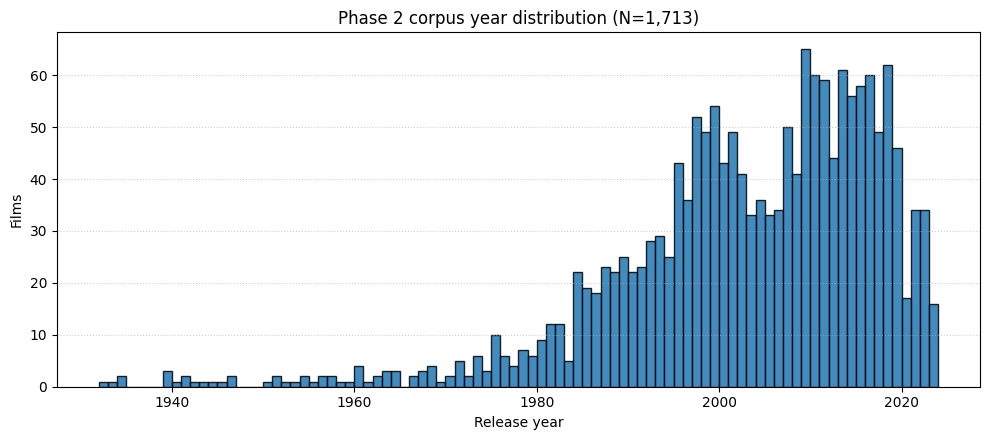

In [19]:
from src.data.validate_processed_corpus import plot_year_distribution

plot_year_distribution(
    df, paths.REPORTS_FIGURES_DIR / "phase2_year_distribution.png"
)
plt.show()

Dense band 1995 to 2022 with a thin tail back to 1932. With the
cutoff reversed, pre-1995 films stay in. Phase 4 era-stratified
CV will bucket pre-1980s decades into a single "older films"
stratum

### 10.2 Genre distribution (bucketed)

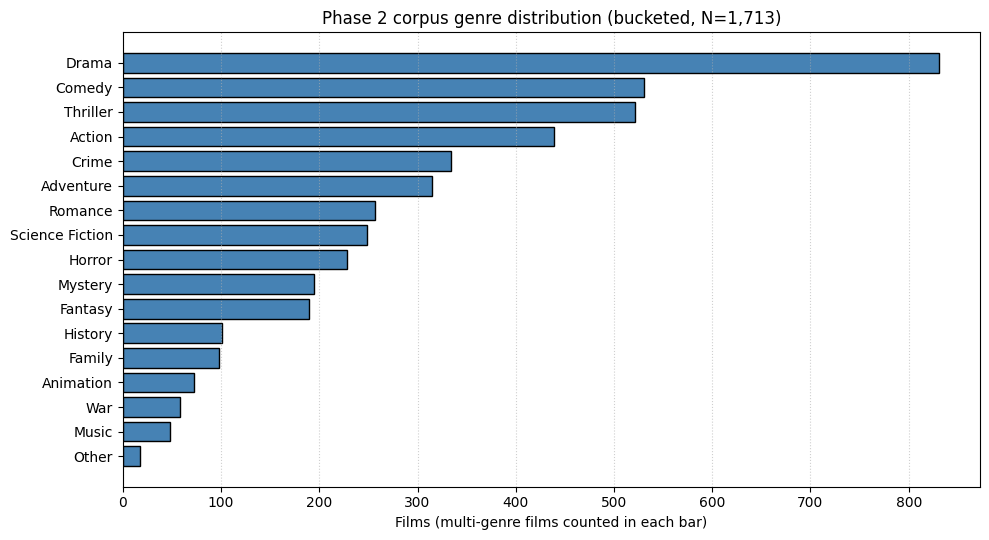

In [20]:
from src.data.validate_processed_corpus import plot_genre_distribution

plot_genre_distribution(
    df, paths.REPORTS_FIGURES_DIR / "phase2_genre_distribution.png"
)
plt.show()

Same Drama / Comedy / Thriller / Action lead. Genres with fewer
than 30 films collapsed into `Other`. The big buckets are
well-conditioned for Phase 4 per-genre CV.

### 10.3 Budget and revenue (raw + log)

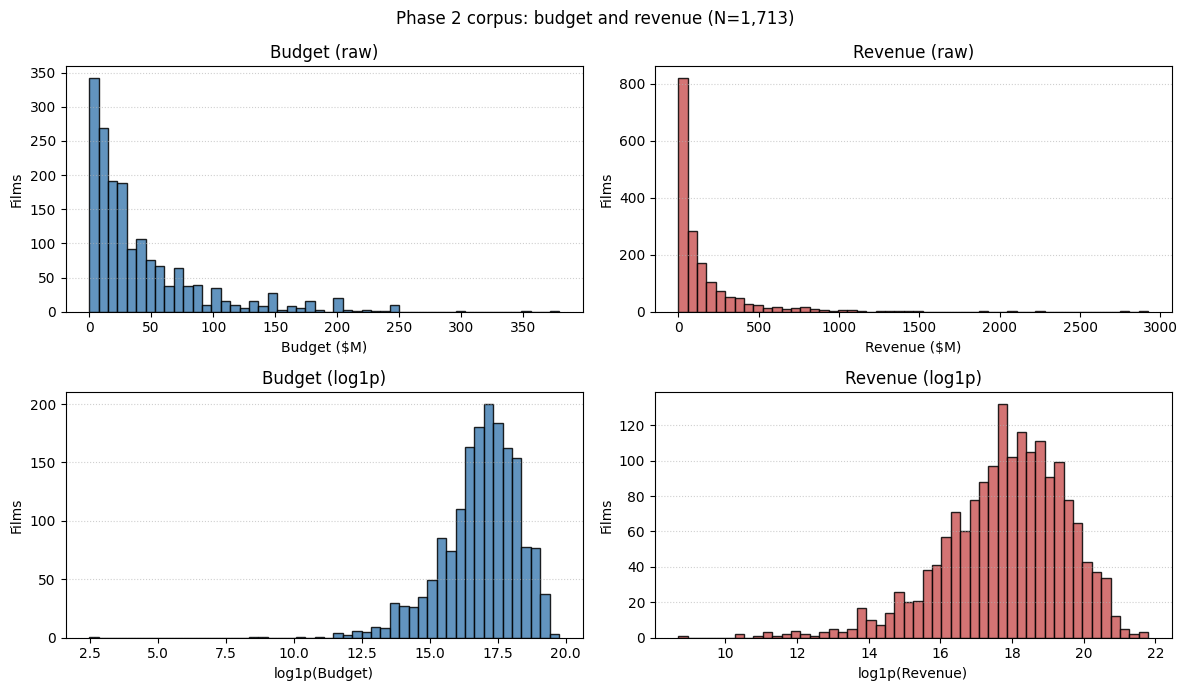

In [21]:
from src.data.validate_processed_corpus import plot_budget_revenue

plot_budget_revenue(
    df, paths.REPORTS_FIGURES_DIR / "phase2_budget_revenue_distribution.png"
)
plt.show()

The raw-scale histograms show the heavy right-skew that
motivated the log transforms. The log1p versions are roughly
bell-shaped, which is what ML models prefer.

### 10.4 Rating, ROI, screenplay length

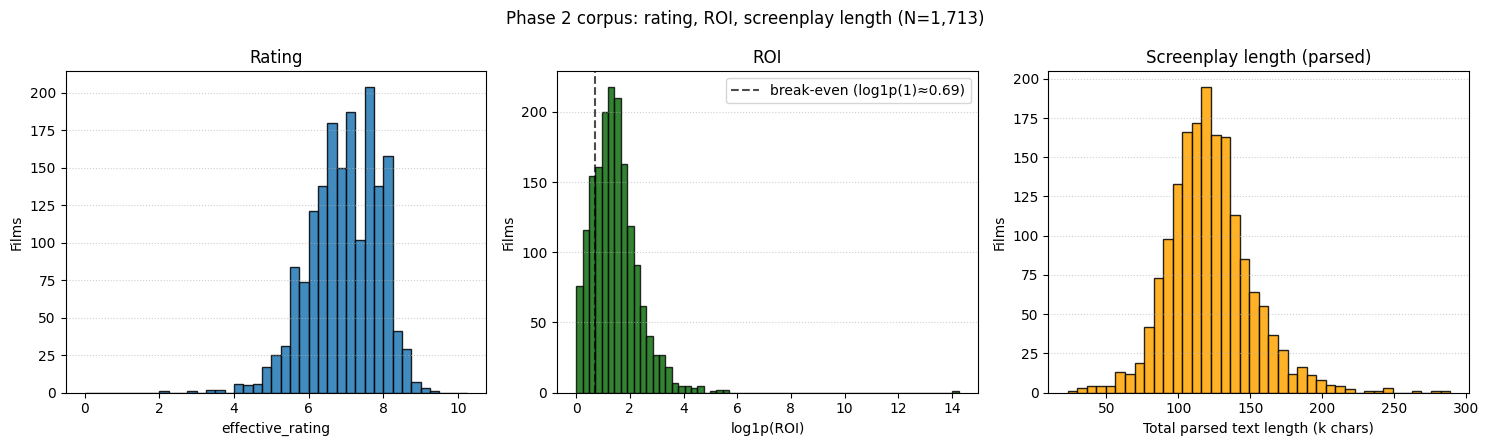

In [22]:
from src.data.validate_processed_corpus import plot_rating_roi_length

plot_rating_roi_length(
    df, paths.REPORTS_FIGURES_DIR / "phase2_rating_roi_length.png"
)
plt.show()

* **Rating** is narrow Gaussian-ish around 7.0. Limited dynamic
  range; The
  asymmetric-cost decision layer in Phase 6 is where the system
  earns its value, not the regression accuracy.
* **ROI** is right-tailed on the raw scale; on the
  log1p scale shown here it's approximately bell-shaped with
  mild right skew. The break-even line (log1p(1) ≈ 0.69) sits
  to the left of most of the mass, which is what produces the
  ~80% gross-profitable rate (note: gross, not net;
  survivorship-biased corpus).
* **Screenplay length** is bell-shaped around 200k characters
  of parsed text (dialogue + action), consistent with
  feature-length conventions.

### 10.5 Screenplay-structural features (new in Phase 2)

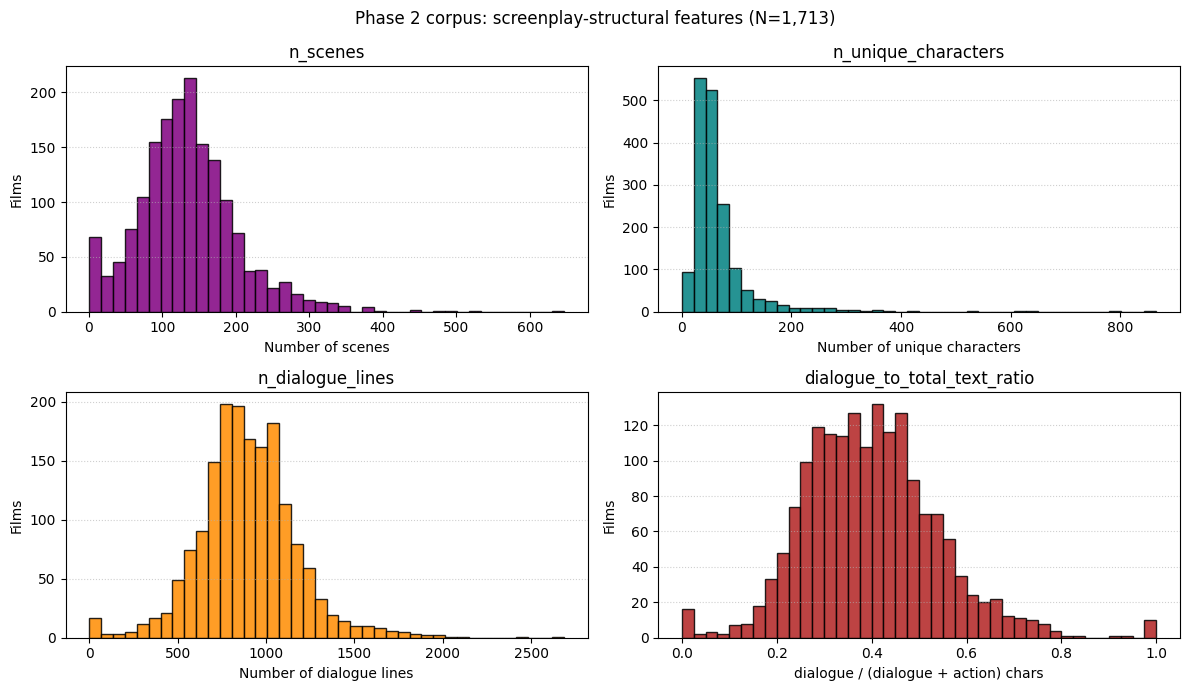

In [23]:
from src.data.validate_processed_corpus import plot_screenplay_structure

plot_screenplay_structure(
    df, paths.REPORTS_FIGURES_DIR / "phase2_screenplay_structure.png"
)
plt.show()

Four distributions for the new screenplay-structural features:

* `n_scenes`: right-skewed, median 130, mean 135. A few
  "long-form" scripts have 400+ scenes.
* `n_unique_characters`: right-skewed, median 51. Most scripts
  have a manageable cast; a few epics have 200+.
* `n_dialogue_lines`: right-skewed, median 880. Roughly mirrors
  script length.
* `dialogue_to_total_text_ratio`: bell-shaped around 0.4. Wide
  spread; some scripts are dialogue-heavy (>0.6), some are
  action-heavy (<0.25). This will likely be a useful Phase 3
  feature.

---

## 11. Per-decade and per-genre tables

Two tables that will inform Phase 4's stratification choices.
Saved to `reports/tables/`.

### 11.1 Per-decade breakdown

In [24]:
from src.data.validate_processed_corpus import per_decade_table
per_decade_table(df)

,decade,n_films,budget_median_M,revenue_median_M,rating_mean,scenes_median,dialogue_lines_median
0,1930,7,0.70,4.50,7.63,2.0,1363.0
1,1940,9,0.88,4.90,8.00,76.0,1061.0
2,1950,14,1.24,9.00,7.91,92.5,1004.5
3,1960,23,2.50,25.00,7.81,98.0,870.0
4,1970,51,3.50,46.67,7.40,90.0,869.0
5,1980,167,15.00,44.80,6.86,128.0,810.0
6,1990,361,30.00,59.49,6.86,127.0,883.0
7,2000,425,40.00,83.28,6.88,141.0,896.0
8,2010,555,25.00,77.07,6.96,130.0,883.0
9,2020,101,35.00,46.33,6.84,117.0,914.0


This shows the decade-level cell counts. 1930s through 1970s
each have under 50 films (most under 20), which is why Phase 4
will bucket them. 1980s onward has well-conditioned per-decade
cells.

### 11.2 Per-genre breakdown

In [25]:
from src.data.validate_processed_corpus import per_genre_table
per_genre_table(df)

,primary_genre_bucketed,n_films,budget_median_M,revenue_median_M,rating_mean,roi_median
5,Drama,431,18.00,40.26,7.09,2.55
3,Comedy,312,18.00,52.50,6.72,3.01
0,Action,239,55.00,139.20,6.92,2.52
9,Horror,147,11.00,47.97,6.63,4.03
1,Adventure,121,65.00,263.92,7.17,3.23
4,Crime,101,18.00,45.28,7.15,2.57
15,Thriller,83,32.00,78.87,6.88,2.48
14,Science Fiction,66,40.00,92.69,6.94,2.46
7,Fantasy,47,54.00,151.93,7.00,3.15
2,Animation,45,80.00,348.84,7.21,3.84


Drama leads, followed by Comedy and Action. Note the median and mean
budget / revenue / rating per genre: Adventure, Animation, War and Family lead on budget and revenue; Action is the most populous big-budget genre.
rating spreads narrowly 6.6–7.4 across genres; Horror sits lowest (6.63)

---

## 12. Phase 2 Conclusion

### What Phase 2 produced

* `data/processed/films_joined.parquet`: 1,713 films x 41
  columns. The canonical processed corpus every later phase
  consumes.
* `data/processed/screenplays_parsed.pkl`: 1,713
  `ParsedScreenplay` objects with full per-scene structure.
* 5 Phase 2 figures + 3 summary tables under `reports/`.
* `docs/DATA_NOTES.md`: standing reference for the corpus
  (column glossary, biases, edge cases).
* Updated `PROJECT_CONTEXT.md` Sections 5, 8, 9; updated
  `CLAUDE_CODE_GUIDELINES.md` template; corrected
  `phase_1_summary.md`.

### Things to remember when reading this corpus later

* **0 is missing for `budget`, `revenue`, `runtime`.** We
  filtered out 0 already, but anyone re-loading the raw data
  must re-apply this convention.
* **Survivorship bias.** ~80% gross-profitable. The model
  predicts triage outcomes for production-ready, recognizable
  scripts, not for a representative random script. Phase 6
  cost matrix must use industry base rates.
* **`<parenthetical>` is recognized but not stored** in
  dialogue tuples (they're 2-tuples per the brief).
* **Two dialogue/action ratios saved**, not one. Pick per task.
* **The pre-1995 cutoff was reversed mid-Phase-2.** Corpus
  retains all 1,713 films across 1932-2023. Era-stratified CV
  in Phase 4 buckets pre-1980s decades.
* **Every preprocessing knob is in `CorpusBuildConfig`.

### Phase 3 prerequisites

Phase 3 reads `films_joined.parquet` for metadata and outcomes,
and `screenplays_parsed.pkl` for the per-film scene structure.
It will:

* Carve a train / calibration / test split from this corpus
  (the split happens in Phase 3, not earlier, to support
  conformal prediction in Phase 5).
* Compute imputation strategy (post-split, to avoid leakage).
* Extract dialogue features (lexical, sentiment, topic,
  embedding, structural).
* Save the feature matrix to `data/processed/features.parquet`.

See `docs/DATA_NOTES.md` for the full column glossary and
`docs/summaries/phase_2_summary.md` for the methodology
rationale and audit trail.